# DeepFake Detection — Celeb-DF v2 Full Pipeline (Kaggle)
### EfficientNet-Lite0 + LSTM | Trained on Celeb-DF v2

**Pipeline Overview:**
1. Install dependencies
2. Verify Kaggle dataset paths
3. Merge real video folders
4. Configure hyperparameters
5. Preprocess videos (face extraction)
6. Split data (70/20/10)
7. Create dataset loaders with augmentation
8. Train, evaluate, and predict

> **Kaggle GPU:** Enable T4 x2 or P100 via *Settings → Accelerator*  
> **Dataset:** Add `reubensuju/celeb-df-v2` via the *Add Data* button


## Step 1 — Setup: Install Dependencies

In [2]:
!pip install -q timm
print("All dependencies installed!")

All dependencies installed!


## Step 2 — Verify Kaggle Dataset Paths

In [3]:
import os

def find_dir(base, must_contain, exclude=()):
    """Find first dir under base whose name contains must_contain but not any exclude keyword."""
    for dirpath, dirnames, _ in os.walk(base):
        level = dirpath.replace(base, '').count(os.sep)
        if level > 3:
            del dirnames[:]
            continue
        for d in dirnames:
            dl = d.lower()
            if must_contain in dl and not any(e in dl for e in exclude):
                return os.path.join(dirpath, d)
    return None

base = '/kaggle/input'
print('Scanning', base, '...')
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    if level > 3:
        del dirs[:]
        continue
    print('  ' * level + os.path.basename(root) + '/')

# Raw dataset: celeb-df but NOT processed
KAGGLE_INPUT = find_dir(base, 'celeb-df', exclude=('processed',))
# Processed dataset: celeb-df-processed
PROCESSED_INPUT = find_dir(base, 'processed')

print('Raw dataset      : ' + str(KAGGLE_INPUT))
print('Processed dataset: ' + str(PROCESSED_INPUT))


Scanning /kaggle/input ...
input/
  datasets/
    arcticfoz/
      celeb-df-processed/
    reubensuju/
      celeb-df-v2/
Raw dataset      : /kaggle/input/datasets/reubensuju/celeb-df-v2
Processed dataset: /kaggle/input/datasets/arcticfoz/celeb-df-processed


## Step 3 — Detect & Merge Dataset Paths

In [4]:
import os, shutil

# ── DEBUG: show exact structure ──────────────────────────────────────────
print('KAGGLE_INPUT =', KAGGLE_INPUT)
print('Direct children:')
for item in sorted(os.listdir(KAGGLE_INPUT)):
    full = os.path.join(KAGGLE_INPUT, item)
    kind = 'DIR' if os.path.isdir(full) else 'FILE'
    print('  [' + kind + ']', item)

# ── Recursive subfolder search ────────────────────────────────────────────
def find_subfolder(root, keywords, max_depth=3):
    for dirpath, dirnames, _ in os.walk(root):
        level = dirpath.replace(root, '').count(os.sep)
        if level > max_depth:
            del dirnames[:]
            continue
        for d in dirnames:
            if any(k in d.lower() for k in keywords):
                return os.path.join(dirpath, d)
    raise FileNotFoundError('No match for ' + str(keywords) + ' under ' + root)

CELEB_REAL   = find_subfolder(KAGGLE_INPUT, ('celeb-real',))
YOUTUBE_REAL = find_subfolder(KAGGLE_INPUT, ('youtube-real',))
CELEB_FAKE   = find_subfolder(KAGGLE_INPUT, ('synthesis', 'celeb-synthesis'))

print('Celeb-real   : ' + CELEB_REAL)
print('YouTube-real : ' + YOUTUBE_REAL)
print('Celeb-fake   : ' + CELEB_FAKE)

MERGED_REAL = '/kaggle/working/merged_real'
os.makedirs(MERGED_REAL, exist_ok=True)

print('Merging real video folders...')
for src_folder, tag in [(CELEB_REAL, 'celeb'), (YOUTUBE_REAL, 'yt')]:
    for f in os.listdir(src_folder):
        if f.endswith('.mp4'):
            dst = os.path.join(MERGED_REAL, tag + '_' + f)
            if not os.path.exists(dst):
                shutil.copy(os.path.join(src_folder, f), dst)

n_real = len([f for f in os.listdir(MERGED_REAL) if f.endswith('.mp4')])
n_fake = len([f for f in os.listdir(CELEB_FAKE)  if f.endswith('.mp4')])

print('Real videos : ' + str(n_real))
print('Fake videos : ' + str(n_fake))
print('Total       : ' + str(n_real + n_fake))

RAW_REAL_DETECTED = MERGED_REAL
RAW_FAKE_DETECTED = CELEB_FAKE
print('RAW_REAL -> ' + RAW_REAL_DETECTED)
print('RAW_FAKE -> ' + RAW_FAKE_DETECTED)


KAGGLE_INPUT = /kaggle/input/datasets/reubensuju/celeb-df-v2
Direct children:
  [DIR] Celeb-real
  [DIR] Celeb-synthesis
  [FILE] List_of_testing_videos.txt
  [DIR] YouTube-real
Celeb-real   : /kaggle/input/datasets/reubensuju/celeb-df-v2/Celeb-real
YouTube-real : /kaggle/input/datasets/reubensuju/celeb-df-v2/YouTube-real
Celeb-fake   : /kaggle/input/datasets/reubensuju/celeb-df-v2/Celeb-synthesis
Merging real video folders...
Real videos : 890
Fake videos : 5639
Total       : 6529
RAW_REAL -> /kaggle/working/merged_real
RAW_FAKE -> /kaggle/input/datasets/reubensuju/celeb-df-v2/Celeb-synthesis


## Step 4 — Configuration

In [ ]:
import torch, os
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

SPLIT_DIR  = '/kaggle/working/splitted_data'
MODEL_PATH = '/kaggle/working/best_model.pth'

# If user has a pre-processed dataset, use it directly — skip face extraction
if PROCESSED_INPUT is not None:
    proc_real = os.path.join(PROCESSED_INPUT, 'real')
    proc_fake = os.path.join(PROCESSED_INPUT, 'fake')
    # Check one level deeper (processed/real, processed/fake)
    if not os.path.isdir(proc_real):
        for sub in os.listdir(PROCESSED_INPUT):
            candidate = os.path.join(PROCESSED_INPUT, sub)
            if os.path.isdir(candidate):
                if os.path.isdir(os.path.join(candidate, 'real')):
                    proc_real = os.path.join(candidate, 'real')
                    proc_fake = os.path.join(candidate, 'fake')
                    break
    PROCESSED_DIR  = os.path.dirname(proc_real)  # .../processed/
    RAW_REAL       = proc_real
    RAW_FAKE       = proc_fake
    SKIP_EXTRACTION = True
    print('Pre-processed dataset found — face extraction will be skipped.')
    print('  real : ' + proc_real + '  (' + str(len(os.listdir(proc_real))) + ' videos)')
    print('  fake : ' + proc_fake + '  (' + str(len(os.listdir(proc_fake))) + ' videos)')
else:
    PROCESSED_DIR   = '/kaggle/working/processed'
    RAW_REAL        = RAW_REAL_DETECTED
    RAW_FAKE        = RAW_FAKE_DETECTED
    SKIP_EXTRACTION = False
    print('No pre-processed dataset — will run face extraction.')

# Hyperparameters
FRAME_LIMIT      = 100
FRAME_SKIP       = 2
FRAMES_PER_VIDEO = 15
BATCH_SIZE       = 6
EPOCHS           = 30
PATIENCE         = 5
LR               = 1e-4

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device      : ' + DEVICE)
print('Batch size  : ' + str(BATCH_SIZE))
print('Max epochs  : ' + str(EPOCHS))
print('LR          : ' + str(LR))

for cat in ['real', 'fake']:
    os.makedirs(os.path.join('/kaggle/working/processed', cat), exist_ok=True)
    os.makedirs(os.path.join(SPLIT_DIR, cat), exist_ok=True)
print('Output directories ready.')


def augment_frame(self, frame):
    """Apply data augmentation to a single frame"""
    # Random horizontal flip
    if np.random.random() > 0.5:
        frame = cv2.flip(frame, 1)
    
    # Color jitter: brightness, contrast, saturation, hue
    if self.augment and self.config.get('augmentation', {}).get('video', {}).get('color_jitter', False):
        # Brightness
        if np.random.random() > 0.5:
            factor = np.random.uniform(0.7, 1.3)
            frame = np.clip(frame * factor, 0, 255).astype(np.uint8)
        
        # Contrast
        if np.random.random() > 0.5:
            mean = frame.mean()
            factor = np.random.uniform(0.7, 1.3)
            frame = np.clip((frame - mean) * factor + mean, 0, 255).astype(np.uint8)
        
        # Saturation and Hue (operate in HSV space)
        hsv = cv2.cvtColor(frame, cv2.COLOR_RGB2HSV).astype(np.float32)
        
        if np.random.random() > 0.5:  # Saturation
            hsv[:, :, 1] = np.clip(hsv[:, :, 1] * np.random.uniform(0.7, 1.3), 0, 255)
        
        if np.random.random() > 0.5:  # Hue
            hsv[:, :, 0] = (hsv[:, :, 0] + np.random.uniform(-18, 18)) % 180
        
        frame = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
    
    return frame


Pre-processed dataset found — face extraction will be skipped.
  real : /kaggle/input/datasets/arcticfoz/celeb-df-processed/processed/real  (881 videos)
  fake : /kaggle/input/datasets/arcticfoz/celeb-df-processed/processed/fake  (2081 videos)
Device      : cuda
Batch size  : 6
Max epochs  : 30
LR          : 0.0001
Output directories ready.


## Step 5 — Preprocessing: Face Extraction (MTCNN)
Each video is processed frame-by-frame. MTCNN detects and crops the face, then saves a **face-only video** (112×112px, 15fps).

> This step saves results to Drive — **safe to re-run**, already processed videos are skipped.

In [6]:
if SKIP_EXTRACTION:
    print('Skipping face extraction — using pre-processed dataset.')
    print('Real videos ready: ' + RAW_REAL)
    print('Fake videos ready: ' + RAW_FAKE)
else:
    import cv2
    import numpy as np
    from concurrent.futures import ProcessPoolExecutor, as_completed
    
    # ── Worker initializer: each subprocess gets its own CascadeClassifier ───
    def _worker_init():
        global _face_cascade
        _face_cascade = cv2.CascadeClassifier(
            cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        )
    
    def _detect_face(frame_rgb):
        gray  = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2GRAY)
        faces = _face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4, minSize=(60,60))
        if len(faces) == 0:
            return None
        x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
        pad = int(0.2 * max(w, h))
        x1, y1 = max(0, x-pad), max(0, y-pad)
        x2, y2 = min(frame_rgb.shape[1], x+w+pad), min(frame_rgb.shape[0], y+h+pad)
        return frame_rgb[y1:y2, x1:x2]
    
    # ── Per-video worker (receives a tuple of args) ───────────────────────────
    def _process_video_worker(args):
        src_path, dst_path, frame_limit, frame_skip = args
        if os.path.exists(dst_path):
            return "skip"
        cap = cv2.VideoCapture(src_path)
        face_frames, frame_idx, processed = [], 0, 0
        while cap.isOpened() and processed < frame_limit:
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.resize(frame, (frame.shape[1]//2, frame.shape[0]//2))
            rgb   = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            face  = _detect_face(rgb)
            if face is not None and face.size > 0:
                face_bgr = cv2.cvtColor(cv2.resize(face, (112,112)), cv2.COLOR_RGB2BGR)
                face_frames.append(face_bgr)
                processed += 1
            frame_idx += frame_skip
        cap.release()
        if face_frames:
            writer = cv2.VideoWriter(dst_path, cv2.VideoWriter_fourcc(*"mp4v"), 15, (112,112))
            for f in face_frames:
                writer.write(f)
            writer.release()
            return "ok"
        return "fail"
    
    # ── Parallel folder preprocessor (4 workers = all Kaggle CPU cores) ──────
    def preprocess_folder(src_folder, dst_folder, label, num_workers=4):
        videos    = [f for f in os.listdir(src_folder) if f.endswith(".mp4")]
        args_list = [
            (os.path.join(src_folder, v), os.path.join(dst_folder, v), FRAME_LIMIT, FRAME_SKIP)
            for v in videos
        ]
        ok, fail, skip = 0, 0, 0
        with ProcessPoolExecutor(max_workers=num_workers, initializer=_worker_init) as pool:
            futures = {pool.submit(_process_video_worker, a): i for i, a in enumerate(args_list)}
            for i, fut in enumerate(as_completed(futures)):
                r = fut.result()
                if r == "ok":     ok   += 1
                elif r == "fail": fail += 1
                else:             skip += 1
                if (i+1) % 100 == 0:
                    print(f"  [{label}] {i+1}/{len(videos)} | saved={ok} no_face={fail} skipped={skip}")
        print(f"[{label}] Done: {ok} saved, {fail} no face, {skip} already existed")
        return ok
    
    print("Processing REAL videos...")
    n_real_proc = preprocess_folder(RAW_REAL, os.path.join(PROCESSED_DIR, "real"), "REAL")
    print("Processing FAKE videos...")
    n_fake_proc = preprocess_folder(RAW_FAKE, os.path.join(PROCESSED_DIR, "fake"), "FAKE")
    print(f"Preprocessing complete! Real={n_real_proc}, Fake={n_fake_proc}")

Skipping face extraction — using pre-processed dataset.
Real videos ready: /kaggle/input/datasets/arcticfoz/celeb-df-processed/processed/real
Fake videos ready: /kaggle/input/datasets/arcticfoz/celeb-df-processed/processed/fake


### Preprocessing Result — Sample Face Crops

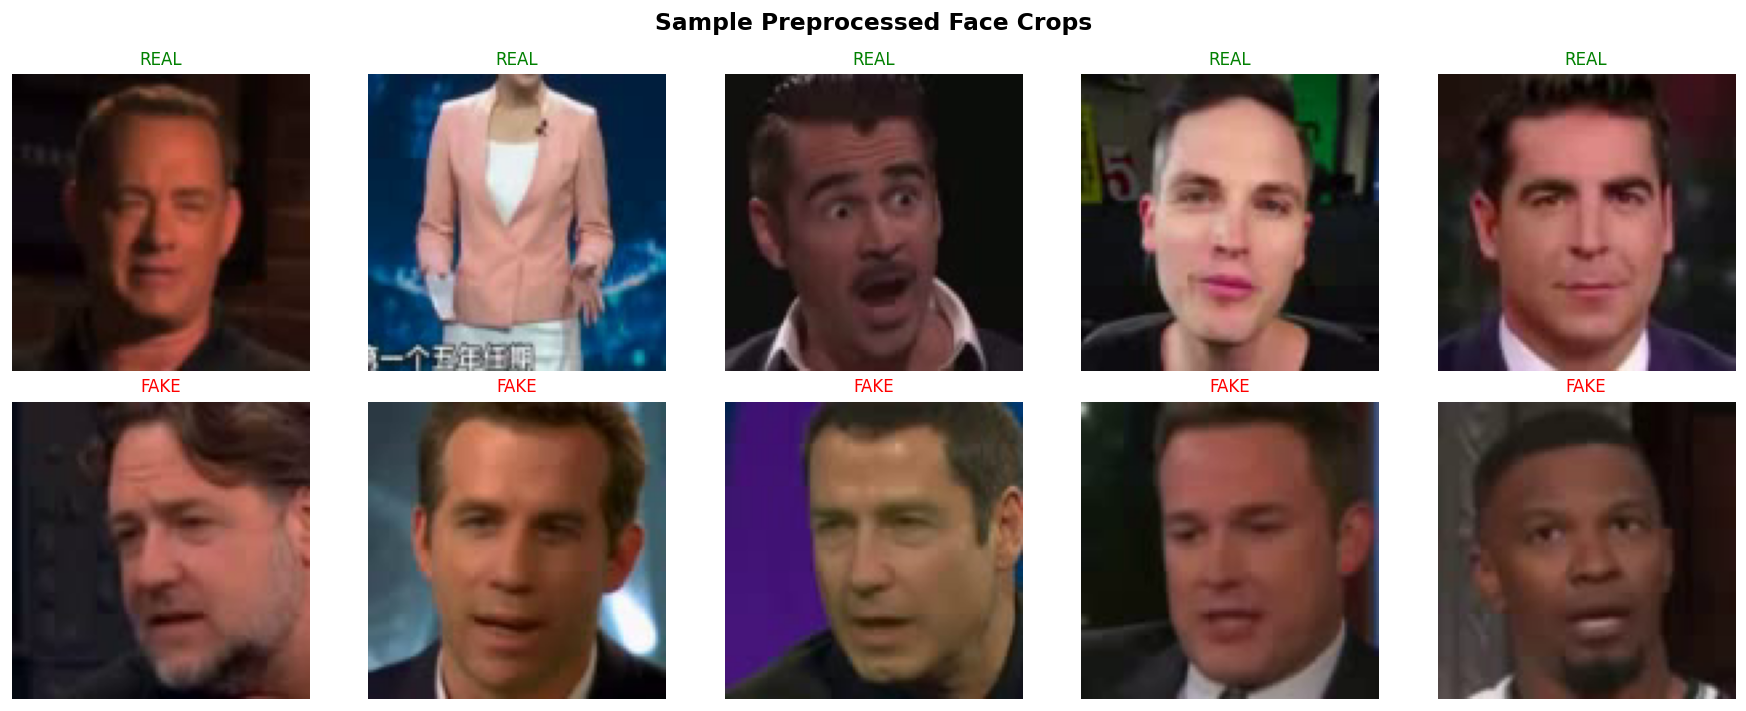

In [7]:
import cv2
import numpy as np
import random
from PIL import Image


def get_sample_frames(video_path, n=5):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total-1, n, dtype=int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames

real_videos = [os.path.join(PROCESSED_DIR,"real",f) for f in os.listdir(os.path.join(PROCESSED_DIR,"real")) if f.endswith(".mp4")]
fake_videos = [os.path.join(PROCESSED_DIR,"fake",f) for f in os.listdir(os.path.join(PROCESSED_DIR,"fake")) if f.endswith(".mp4")]

n_show = 5
fig, axes = plt.subplots(2, n_show, figsize=(15, 6))
fig.suptitle("Sample Preprocessed Face Crops", fontsize=14, fontweight="bold")

for col, vpath in enumerate(random.sample(real_videos, n_show)):
    frames = get_sample_frames(vpath, 1)
    if frames:
        axes[0, col].imshow(frames[0])
    axes[0, col].set_title("REAL", color="green", fontsize=10)
    axes[0, col].axis("off")

for col, vpath in enumerate(random.sample(fake_videos, n_show)):
    frames = get_sample_frames(vpath, 1)
    if frames:
        axes[1, col].imshow(frames[0])
    axes[1, col].set_title("FAKE", color="red", fontsize=10)
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

## Step 6 — Data Splitting (70 / 20 / 10)
> Skip if already split.

In [8]:
import shutil, random

def split_folder(src, dst_root, train_r=0.7, val_r=0.2):
    files = [f for f in os.listdir(src) if f.endswith('.mp4')]
    random.shuffle(files)
    n = len(files)
    splits = {
        'train': files[:int(n*train_r)],
        'val':   files[int(n*train_r):int(n*(train_r+val_r))],
        'test':  files[int(n*(train_r+val_r)):]
    }
    counts = {}
    for split, lst in splits.items():
        dest = os.path.join(dst_root, split)
        os.makedirs(dest, exist_ok=True)
        for f in lst:
            dst_file = os.path.join(dest, f)
            if not os.path.exists(dst_file):
                shutil.copy(os.path.join(src, f), dst_file)
        counts[split] = len(lst)
    return counts

print("Splitting REAL...")
real_counts = split_folder(os.path.join(PROCESSED_DIR,"real"), os.path.join(SPLIT_DIR,"real"))
print("Splitting FAKE...")
fake_counts = split_folder(os.path.join(PROCESSED_DIR,"fake"), os.path.join(SPLIT_DIR,"fake"))

print("\nSplit Summary:")
print(f"{'Split':<10} {'Real':>8} {'Fake':>8} {'Total':>8}")
print("-" * 36)
for split in ['train','val','test']:
    r, f = real_counts[split], fake_counts[split]
    print(f"{split:<10} {r:>8} {f:>8} {r+f:>8}")
print("Splitting complete!")

Splitting REAL...
Splitting FAKE...

Split Summary:
Split          Real     Fake    Total
------------------------------------
train           616     1456     2072
val             176      416      592
test             89      209      298
Splitting complete!


### Dataset Statistics Visualization

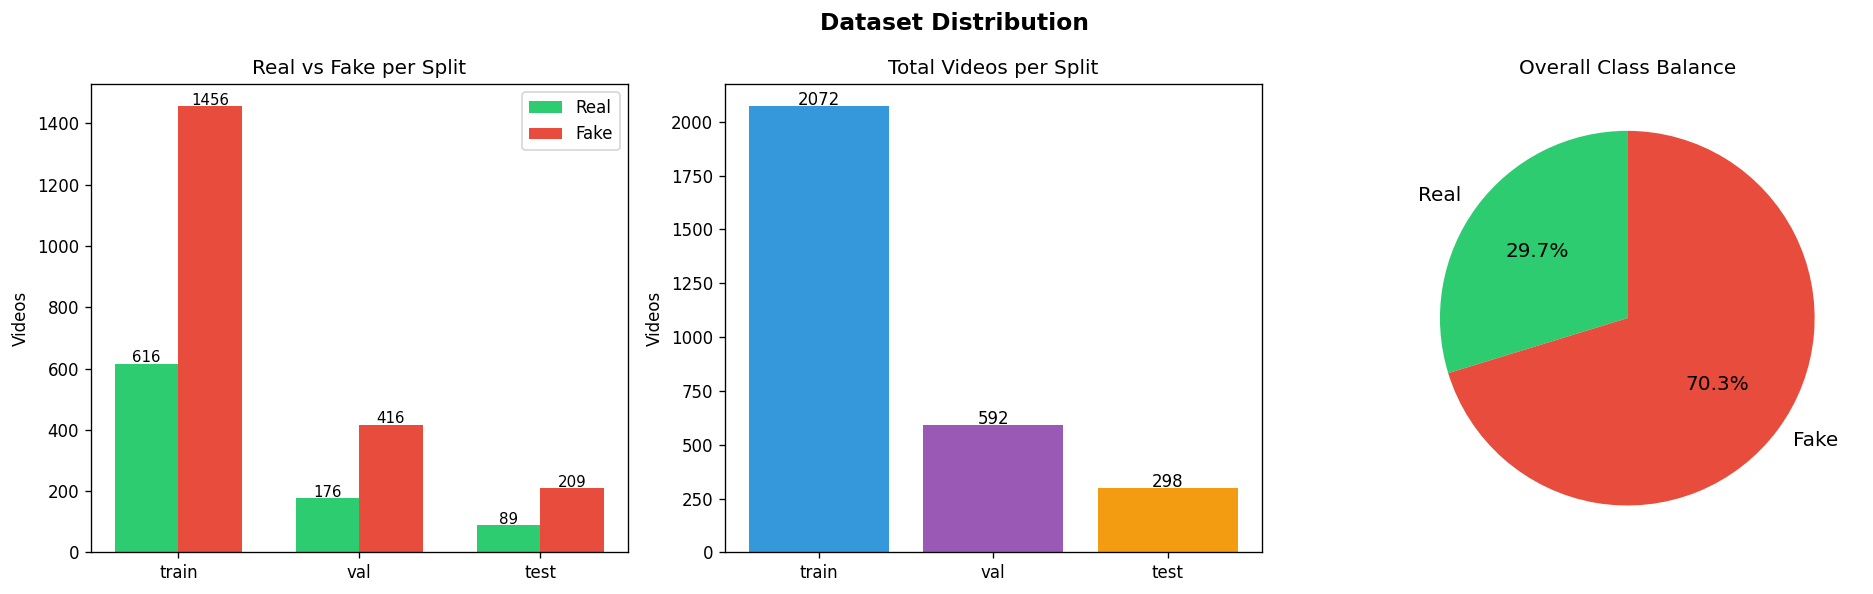

Total dataset: 2962 videos (881 real, 2081 fake)


In [9]:
splits = ['train', 'val', 'test']
real_ns = [real_counts[s] for s in splits]
fake_ns = [fake_counts[s] for s in splits]
total_ns = [r+f for r,f in zip(real_ns, fake_ns)]

x = range(len(splits))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Dataset Distribution", fontsize=14, fontweight="bold")

# Grouped bar chart
axes[0].bar([i - width/2 for i in x], real_ns, width, label='Real', color='#2ecc71')
axes[0].bar([i + width/2 for i in x], fake_ns, width, label='Fake', color='#e74c3c')
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(splits)
axes[0].set_title("Real vs Fake per Split"); axes[0].set_ylabel("Videos")
axes[0].legend()
for i, (r, f) in enumerate(zip(real_ns, fake_ns)):
    axes[0].text(i-width/2, r+5, str(r), ha='center', fontsize=9)
    axes[0].text(i+width/2, f+5, str(f), ha='center', fontsize=9)

# Total per split
colors = ['#3498db','#9b59b6','#f39c12']
bars = axes[1].bar(splits, total_ns, color=colors)
axes[1].set_title("Total Videos per Split"); axes[1].set_ylabel("Videos")
for bar, val in zip(bars, total_ns):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(val), ha='center', fontsize=10)

# Pie chart of overall real vs fake
total_real = sum(real_ns)
total_fake = sum(fake_ns)
axes[2].pie([total_real, total_fake], labels=['Real','Fake'],
            colors=['#2ecc71','#e74c3c'], autopct='%1.1f%%', startangle=90,
            textprops={'fontsize':12})
axes[2].set_title("Overall Class Balance")

plt.tight_layout()
plt.show()
print(f"Total dataset: {total_real + total_fake} videos ({total_real} real, {total_fake} fake)")

## Step 7 — Dataset & DataLoaders

In [10]:
# ── Pre-extract frames from all split videos to JPEG (run once) ──────────
# This converts slow video I/O → fast image I/O during training
import cv2, os
from concurrent.futures import ThreadPoolExecutor

FRAMES_DIR = '/kaggle/working/frames'

def extract_frames_from_video(args):
    video_path, out_dir, fpv = args
    vid_name = os.path.splitext(os.path.basename(video_path))[0]
    frame_dir = os.path.join(out_dir, vid_name)
    if os.path.isdir(frame_dir) and len(os.listdir(frame_dir)) >= fpv:
        return 'skip'
    os.makedirs(frame_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    frames, saved = [], 0
    while cap.isOpened() and saved < fpv:
        ret, frame = cap.read()
        if not ret: break
        frame = cv2.resize(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), (224, 224))
        cv2.imwrite(os.path.join(frame_dir, f'{saved:03d}.jpg'),
                    cv2.cvtColor(frame, cv2.COLOR_RGB2BGR), [cv2.IMWRITE_JPEG_QUALITY, 90])
        saved += 1
    cap.release()
    # Pad with copies of last frame if video was short
    files = sorted(os.listdir(frame_dir))
    while len(files) < fpv and files:
        last = os.path.join(frame_dir, files[-1])
        dst  = os.path.join(frame_dir, f'{len(files):03d}.jpg')
        import shutil; shutil.copy(last, dst)
        files.append(os.path.basename(dst))
    return 'ok'

def extract_split(split, label, label_str):
    src_dir = os.path.join(SPLIT_DIR, label_str, split)
    out_dir = os.path.join(FRAMES_DIR, split, label_str)
    os.makedirs(out_dir, exist_ok=True)
    videos = [os.path.join(src_dir, f) for f in os.listdir(src_dir) if f.endswith('.mp4')]
    args   = [(v, out_dir, FRAMES_PER_VIDEO) for v in videos]
    done = skip = 0
    with ThreadPoolExecutor(max_workers=4) as ex:
        for r in ex.map(extract_frames_from_video, args):
            if r == 'skip': skip += 1
            else: done += 1
    print(f'  {split}/{label_str}: {done} extracted, {skip} skipped')

print('Extracting frames to JPEG...')
for split in ['train', 'val', 'test']:
    extract_split(split, 0, 'real')
    extract_split(split, 1, 'fake')
print('Frame extraction complete! Frames saved to', FRAMES_DIR)


Extracting frames to JPEG...
  train/real: 182 extracted, 616 skipped
  train/fake: 444 extracted, 1456 skipped
  val/real: 139 extracted, 176 skipped
  val/fake: 342 extracted, 416 skipped
  test/real: 81 extracted, 89 skipped
  test/fake: 190 extracted, 209 skipped
Frame extraction complete! Frames saved to /kaggle/working/frames


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

class DeepFakeDataset(Dataset):
    def __init__(self, frames_root, label_str, label, transform=None, fpv=FRAMES_PER_VIDEO):
        # Each video is a subfolder of frames_root/label_str/
        base = os.path.join(frames_root, label_str)
        self.video_dirs = [os.path.join(base, d) for d in os.listdir(base)
                           if os.path.isdir(os.path.join(base, d))]
        self.label     = label
        self.transform = transform
        self.fpv       = fpv

    def __len__(self): return len(self.video_dirs)

    def __getitem__(self, idx):
        frame_files = sorted([
            f for f in os.listdir(self.video_dirs[idx]) if f.endswith('.jpg')
        ])[:self.fpv]
        frames = []
        for ff in frame_files:
            img = cv2.imread(os.path.join(self.video_dirs[idx], ff))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if self.transform:
                img = self.transform(img)
            frames.append(img)
        while len(frames) < self.fpv:
            frames.append(torch.zeros(3, 224, 224))
        return torch.stack(frames), torch.tensor(self.label, dtype=torch.long)

def make_loader(split, tf, shuffle):
    real = DeepFakeDataset(os.path.join(FRAMES_DIR, split), 'real', 0, tf)
    fake = DeepFakeDataset(os.path.join(FRAMES_DIR, split), 'fake', 1, tf)
    ds = real + fake
    print(f'  {split:6}: {len(real)} real + {len(fake)} fake = {len(ds)} total')
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=4, pin_memory=True, persistent_workers=True)

print('Loading datasets...')
train_loader = make_loader('train', train_transform, True)
val_loader   = make_loader('val',   val_transform,   False)
test_loader  = make_loader('test',  val_transform,   False)
print('DataLoaders ready!')


Loading datasets...
  train : 798 real + 1900 fake = 2698 total
  val   : 315 real + 758 fake = 1073 total
  test  : 170 real + 399 fake = 569 total
DataLoaders ready!


### Augmentation Preview
Shows the same frame with different augmentations applied.

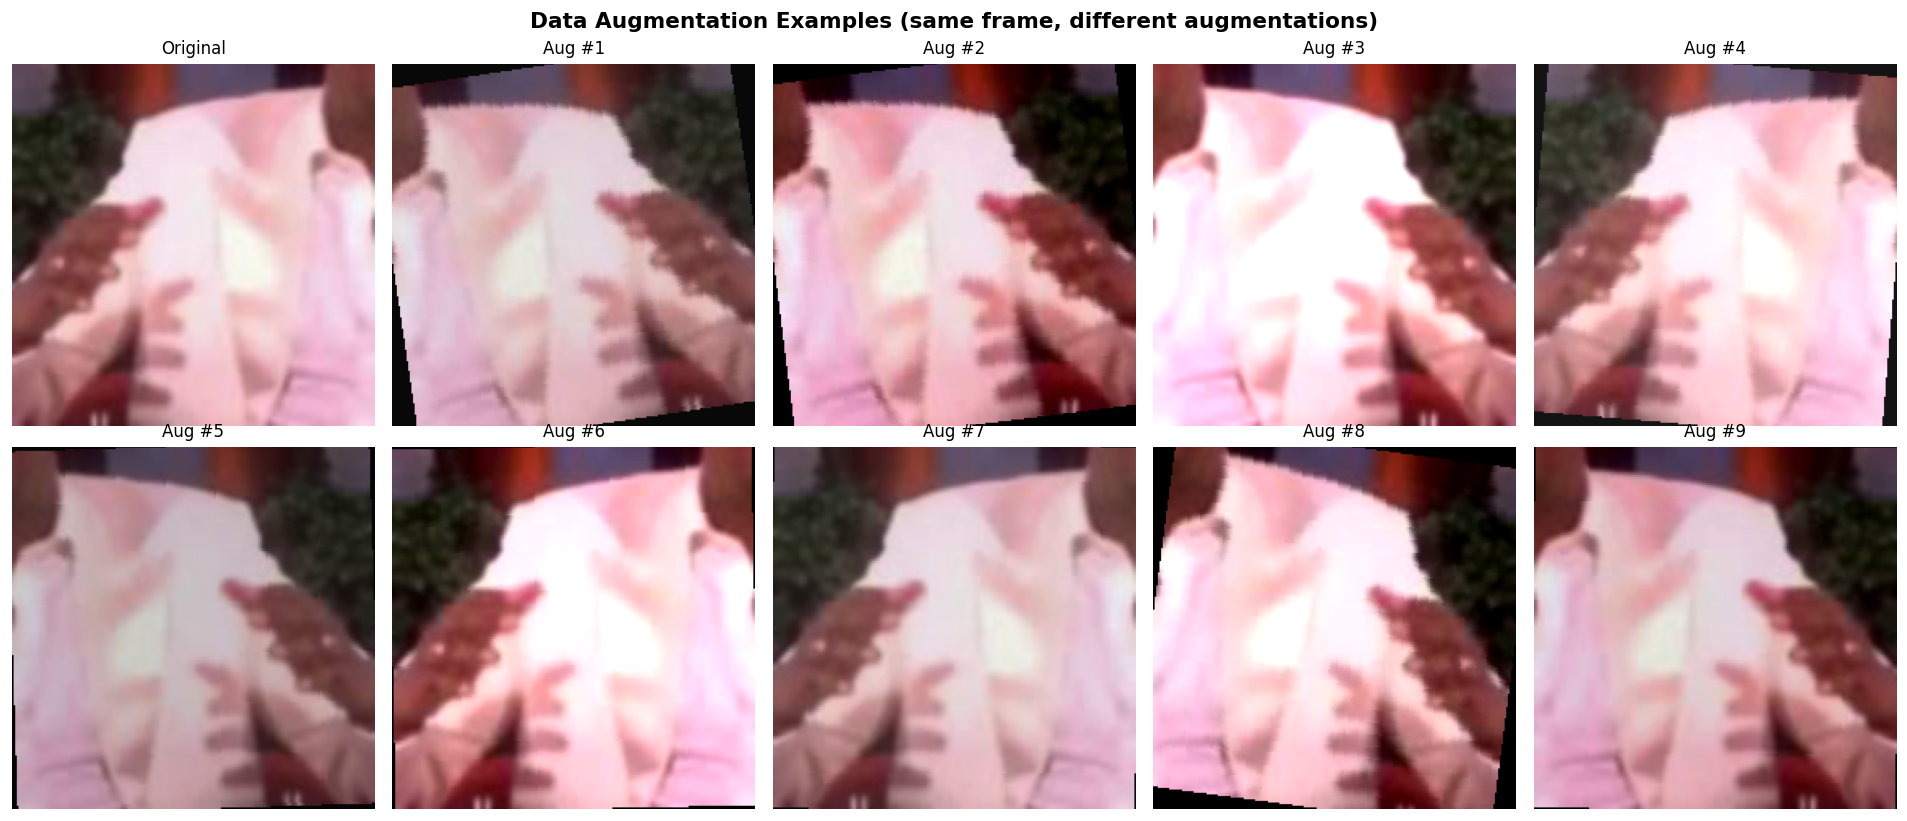

In [12]:
real_vids = [os.path.join(SPLIT_DIR,"real","train",f)
             for f in os.listdir(os.path.join(SPLIT_DIR,"real","train")) if f.endswith(".mp4")]
sample_video = random.choice(real_vids)
cap = cv2.VideoCapture(sample_video)
ret, raw_frame = cap.read()
cap.release()
raw_rgb = cv2.cvtColor(raw_frame, cv2.COLOR_BGR2RGB)
raw_rgb = cv2.resize(raw_rgb, (224, 224))

from PIL import Image as PILImage
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle("Data Augmentation Examples (same frame, different augmentations)", fontsize=13, fontweight="bold")

axes[0,0].imshow(raw_rgb); axes[0,0].set_title("Original", fontsize=10); axes[0,0].axis("off")

for i in range(1, 10):
    aug = train_transform(raw_rgb)
    img = aug.permute(1,2,0).numpy()
    img = (img * 0.5 + 0.5).clip(0,1)
    r, c = divmod(i, 5)
    axes[r,c].imshow(img)
    axes[r,c].set_title(f"Aug #{i}", fontsize=10)
    axes[r,c].axis("off")

plt.tight_layout()
plt.show()

## Step 8 — Model Architecture
**EfficientNet-Lite0** extracts spatial features from each frame, then an **LSTM** models temporal patterns across the 30-frame sequence.

```
Input: (Batch, 30 frames, 3, 224, 224)
  └─> EfficientNet-Lite0 (per frame)  →  1280-dim feature
  └─> LSTM (2 layers, hidden=256)     →  temporal context
  └─> FC (256 → 128 → 2)             →  Real / Fake
```

In [13]:
class DeepFakeDetector(nn.Module):
    def __init__(self):
        super().__init__()
        try:
            self.cnn = timm.create_model("efficientnet_lite0", pretrained=True)
        except Exception:
            print("WARNING: Could not download pretrained weights (no internet). Using random init.")
            self.cnn = timm.create_model("efficientnet_lite0", pretrained=False)
        self.cnn.classifier = nn.Identity()
        self.dropout = nn.Dropout(0.4)
        self.lstm = nn.LSTM(input_size=1280, hidden_size=256, num_layers=2,
                            batch_first=True, dropout=0.3)
        self.fc = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 2)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        feats = self.cnn(x.view(B * T, C, H, W))
        feats = self.dropout(feats).view(B, T, -1)
        out, _ = self.lstm(feats)
        return self.fc(out[:, -1, :])

model = DeepFakeDetector().to(DEVICE)
# Single GPU — DataParallel removed (overhead > benefit for this batch size)
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Model device         : {DEVICE}")

model.safetensors:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Total parameters     : 5,505,410
Trainable parameters : 5,505,410
Model device         : cuda


### Model Architecture Diagram

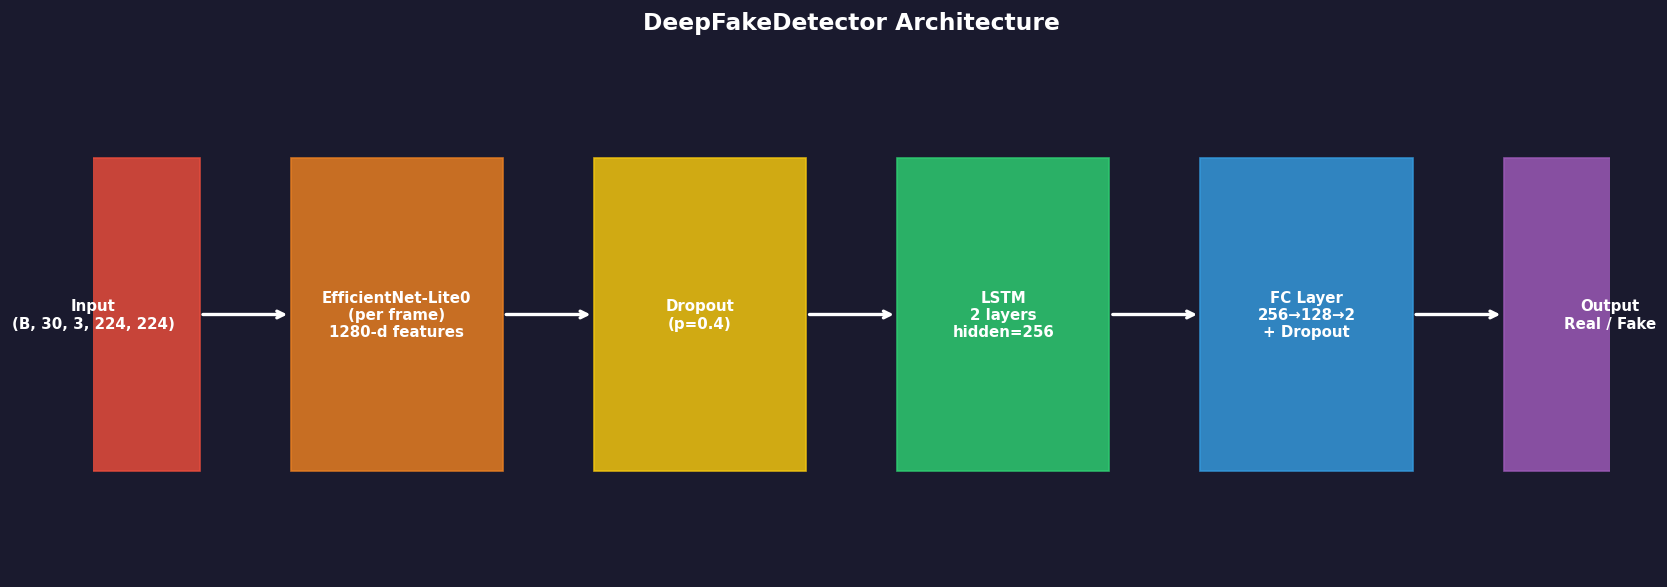

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis("off")
fig.patch.set_facecolor("#1a1a2e")

blocks = [
    ("Input\n(B, 30, 3, 224, 224)", "#e74c3c"),
    ("EfficientNet-Lite0\n(per frame)\n1280-d features", "#e67e22"),
    ("Dropout\n(p=0.4)", "#f1c40f"),
    ("LSTM\n2 layers\nhidden=256", "#2ecc71"),
    ("FC Layer\n256→128→2\n+ Dropout", "#3498db"),
    ("Output\nReal / Fake", "#9b59b6"),
]

n = len(blocks)
for i, (label, color) in enumerate(blocks):
    x = i / (n-1)
    rect = plt.Rectangle((x - 0.07, 0.2), 0.14, 0.6, color=color, alpha=0.85, transform=ax.transAxes)
    ax.add_patch(rect)
    ax.text(x, 0.5, label, ha='center', va='center', fontsize=9, fontweight='bold',
            color='white', transform=ax.transAxes, wrap=True,
            bbox=dict(boxstyle='round,pad=0.1', facecolor='none', edgecolor='none'))
    if i < n-1:
        ax.annotate("", xy=((i+1)/(n-1) - 0.07, 0.5),
                    xytext=(x + 0.07, 0.5),
                    xycoords='axes fraction', textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='white', lw=2))

ax.set_title("DeepFakeDetector Architecture", color='white', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## Step 9 — Training

In [15]:
import time
from tqdm.notebook import tqdm

# ── GPU sanity check ─────────────────────────────────────────────────────
print('DEVICE              :', DEVICE)
print('CUDA available      :', torch.cuda.is_available())
print('GPU count           :', torch.cuda.device_count())
if torch.cuda.is_available():
    print('GPU name            :', torch.cuda.get_device_name(0))
    t = torch.randn(1000,1000).cuda()
    _ = t @ t  # force a GPU op
    print('GPU test op         : OK')
next_param = next(model.parameters())
print('Model on            :', next_param.device)
print()

# ── Time first batch to detect DataLoader bottleneck ────────────────────
print('Timing first batch...')
t0 = time.time()
videos, labels = next(iter(train_loader))
print(f'First batch loaded in {time.time()-t0:.2f}s  shape={tuple(videos.shape)}')
t1 = time.time()
videos, labels = videos.to(DEVICE), labels.to(DEVICE)
with torch.amp.autocast(device_type=DEVICE, enabled=(DEVICE=='cuda')):
    out = model(videos)
print(f'First forward pass  : {time.time()-t1:.2f}s')
print()

# ── Training ─────────────────────────────────────────────────────────────
best_val_loss = float('inf')
if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    print('Resumed from checkpoint!')
else:
    print('Starting fresh training...')

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
use_amp   = DEVICE == 'cuda'
scaler    = torch.amp.GradScaler(enabled=use_amp)

train_losses, val_losses, train_accs, val_accs, lr_history = [], [], [], [], []
patience_ctr = 0

print(f'Training up to {EPOCHS} epochs | patience={PATIENCE}')
print('=' * 80)

for epoch in range(EPOCHS):
    model.train()
    t_loss, t_preds, t_labels = 0, [], []
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]', leave=False)
    for videos, labels in pbar:
        videos, labels = videos.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type=DEVICE, enabled=use_amp):
            out  = model(videos)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        t_loss += loss.item()
        t_preds.extend(torch.argmax(out, 1).cpu().numpy())
        t_labels.extend(labels.cpu().numpy())
        pbar.set_postfix(loss=f'{loss.item():.4f}')
    train_losses.append(t_loss / len(train_loader))
    train_accs.append(accuracy_score(t_labels, t_preds))

    model.eval()
    v_loss, v_preds, v_labels = 0, [], []
    with torch.no_grad():
        for videos, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]', leave=False):
            videos, labels = videos.to(DEVICE), labels.to(DEVICE)
            with torch.amp.autocast(device_type=DEVICE, enabled=use_amp):
                out  = model(videos)
                loss = criterion(out, labels)
            v_loss += loss.item()
            v_preds.extend(torch.argmax(out, 1).cpu().numpy())
            v_labels.extend(labels.cpu().numpy())
    val_losses.append(v_loss / len(val_loader))
    val_accs.append(accuracy_score(v_labels, v_preds))
    lr_history.append(optimizer.param_groups[0]['lr'])
    scheduler.step()

    print(f'Epoch [{epoch+1:02}/{EPOCHS}]  '
          f'Train Loss: {train_losses[-1]:.4f}  Acc: {train_accs[-1]*100:.1f}%  |  '
          f'Val Loss: {val_losses[-1]:.4f}  Acc: {val_accs[-1]*100:.1f}%')

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save(model.state_dict(), MODEL_PATH)
        print('  -> Best model saved!')
        patience_ctr = 0
    else:
        patience_ctr += 1
        print(f'  -> No improvement ({patience_ctr}/{PATIENCE})')
        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

print('=' * 80)
print('Training complete! Model saved to:', MODEL_PATH)


DEVICE              : cuda
CUDA available      : True
GPU count           : 2
GPU name            : Tesla T4
GPU test op         : OK
Model on            : cuda:0

Timing first batch...
First batch loaded in 1.23s  shape=(6, 15, 3, 224, 224)
First forward pass  : 4.77s

Starting fresh training...
Training up to 30 epochs | patience=5


Epoch 1/30 [Train]:   0%|          | 0/450 [00:00<?, ?it/s]

Epoch 1/30 [Val]:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch [01/30]  Train Loss: 0.5127  Acc: 75.7%  |  Val Loss: 0.3879  Acc: 82.1%
  -> Best model saved!


Epoch 2/30 [Train]:   0%|          | 0/450 [00:00<?, ?it/s]

...

Epoch 14/30 [Val]:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch [14/30]  Train Loss: 0.0523  Acc: 98.3%  |  Val Loss: 0.3033  Acc: 91.6%
  -> No improvement (4/5)


Epoch 15/30 [Train]:   0%|          | 0/450 [00:00<?, ?it/s]

Epoch 15/30 [Val]:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch [15/30]  Train Loss: 0.0510  Acc: 98.3%  |  Val Loss: 0.1534  Acc: 95.1%
  -> No improvement (5/5)
Early stopping at epoch 15
Training complete! Model saved to: /kaggle/working/best_model.pth


## Training Curves

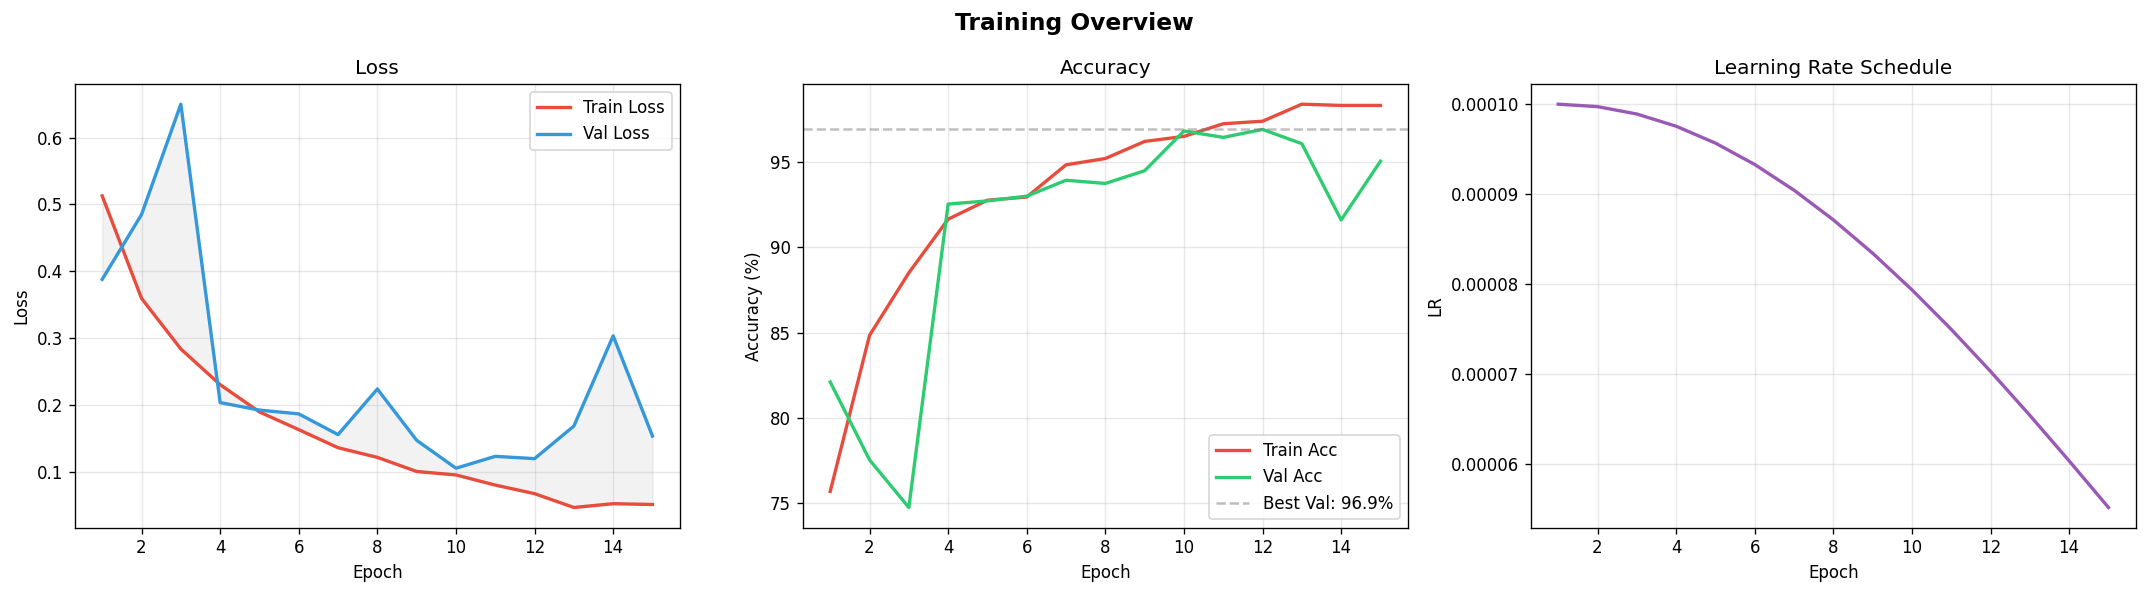

Best Val Accuracy : 96.92%
Best Val Loss     : 0.1053
Epochs trained    : 15


In [16]:
epochs_ran = range(1, len(train_losses)+1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training Overview", fontsize=14, fontweight="bold")

# Loss
axes[0].plot(epochs_ran, train_losses, label='Train Loss', color='#e74c3c', linewidth=2)
axes[0].plot(epochs_ran, val_losses,   label='Val Loss',   color='#3498db', linewidth=2)
axes[0].fill_between(epochs_ran, train_losses, val_losses, alpha=0.1, color='gray')
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_ran, [a*100 for a in train_accs], label='Train Acc', color='#e74c3c', linewidth=2)
axes[1].plot(epochs_ran, [a*100 for a in val_accs],   label='Val Acc',   color='#2ecc71', linewidth=2)
axes[1].axhline(max(val_accs)*100, linestyle='--', color='gray', alpha=0.5,
                label=f'Best Val: {max(val_accs)*100:.1f}%')
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(alpha=0.3)

# Learning Rate
axes[2].plot(epochs_ran, lr_history, color='#9b59b6', linewidth=2)
axes[2].set_title("Learning Rate Schedule"); axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("LR")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best Val Accuracy : {max(val_accs)*100:.2f}%")
print(f"Best Val Loss     : {min(val_losses):.4f}")
print(f"Epochs trained    : {len(train_losses)}")

## Step 10 — Evaluation on Test Set

In [17]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, precision_recall_curve)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for videos, labels in test_loader:
        videos, labels = videos.to(DEVICE), labels.to(DEVICE)
        out   = model(videos)
        probs = torch.softmax(out, dim=1)
        preds = torch.argmax(out, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())  # fake probability

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=['Real','Fake'], digits=4))

Classification Report:
              precision    recall  f1-score   support

        Real     0.9515    0.9235    0.9373       170
        Fake     0.9678    0.9799    0.9738       399

    accuracy                         0.9631       569
   macro avg     0.9597    0.9517    0.9556       569
weighted avg     0.9629    0.9631    0.9629       569



### Evaluation Visualizations

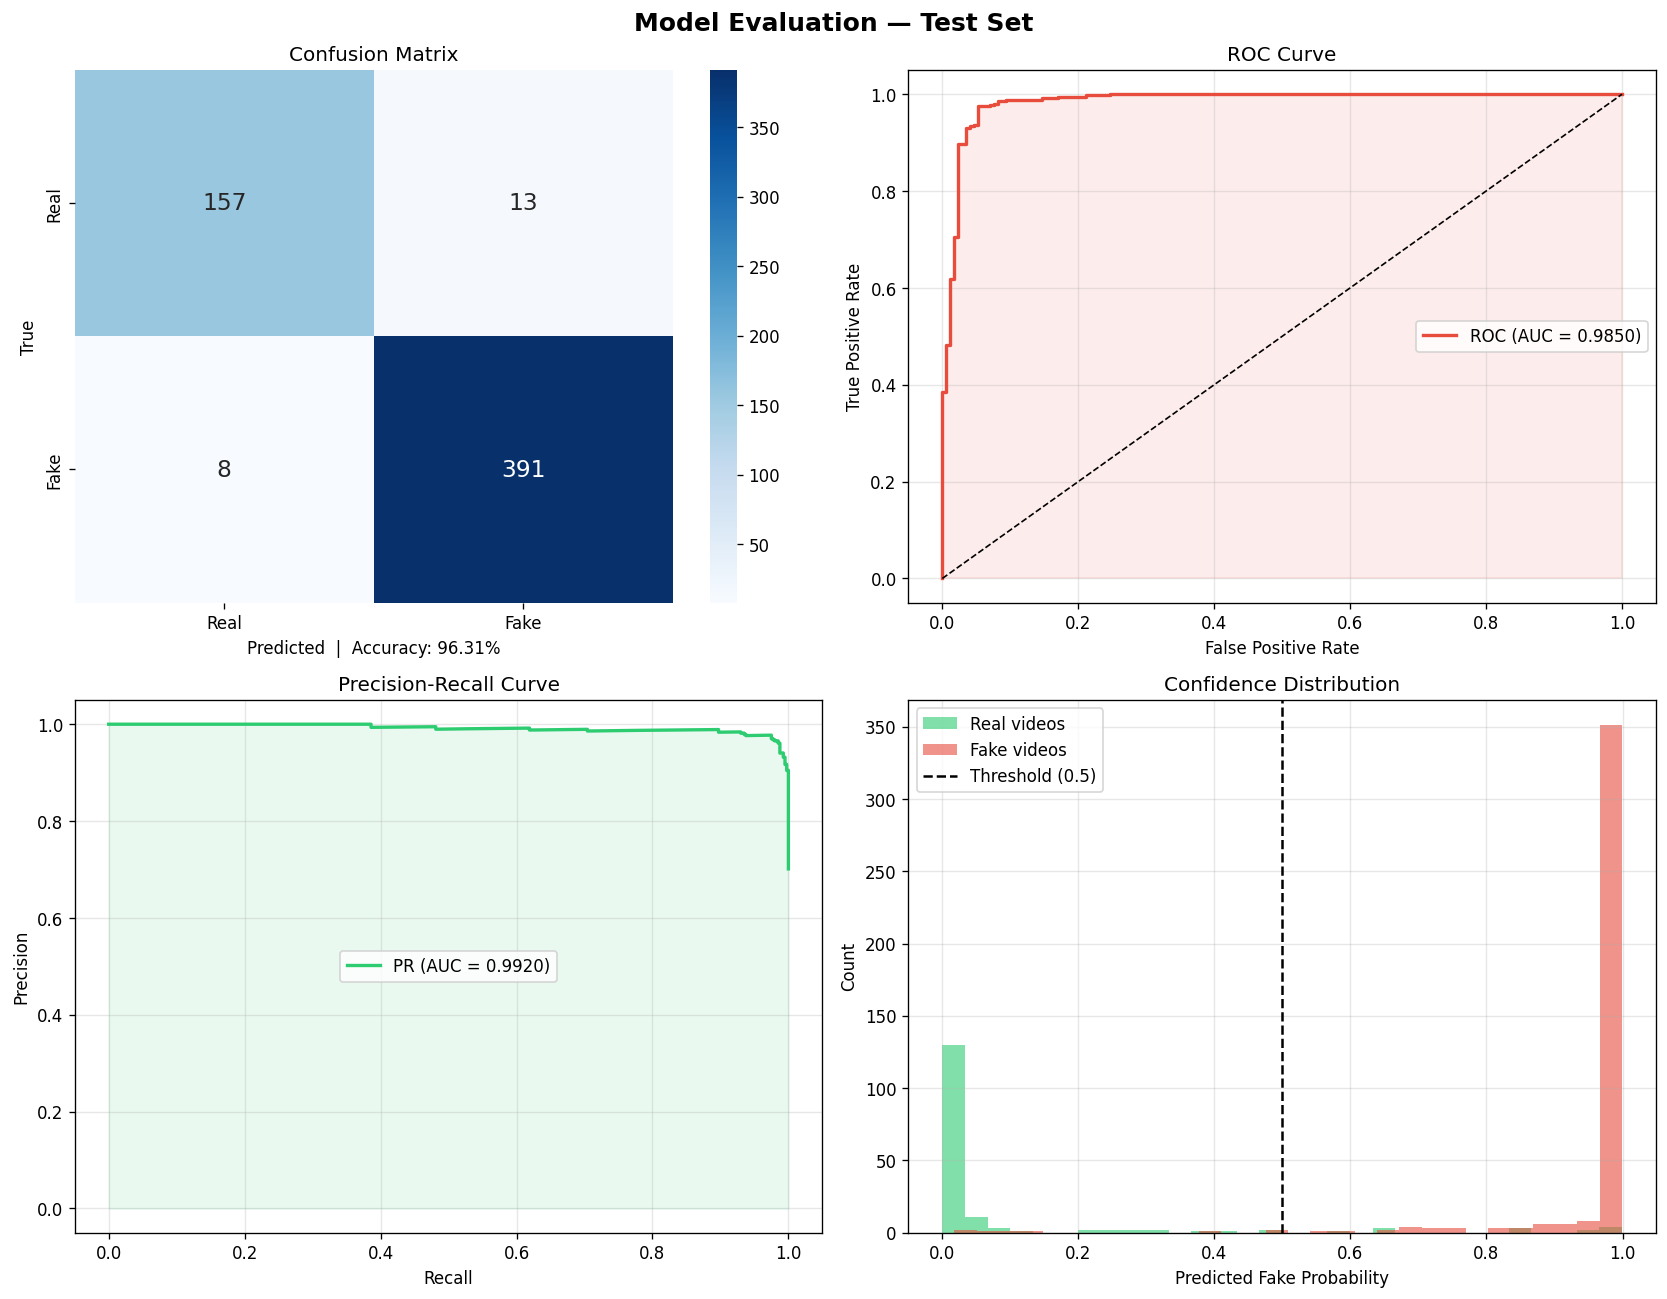

ROC-AUC  : 0.9850
PR-AUC   : 0.9920


In [18]:
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Model Evaluation — Test Set", fontsize=15, fontweight="bold")

# ── Confusion Matrix ───────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Real','Fake'], yticklabels=['Real','Fake'],
            annot_kws={"size": 14})
axes[0,0].set_xlabel('Predicted'); axes[0,0].set_ylabel('True')
axes[0,0].set_title('Confusion Matrix')
tn,fp,fn,tp = cm.ravel()
axes[0,0].set_xlabel(f'Predicted  |  Accuracy: {(tn+tp)/(tn+fp+fn+tp)*100:.2f}%')

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
axes[0,1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[0,1].plot([0,1],[0,1], 'k--', lw=1)
axes[0,1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0,1].set_xlabel('False Positive Rate'); axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# ── Precision-Recall Curve ────────────────────────────────────────────────────
prec, rec, _ = precision_recall_curve(all_labels, all_probs)
pr_auc = auc(rec, prec)
axes[1,0].plot(rec, prec, color='#2ecc71', lw=2, label=f'PR (AUC = {pr_auc:.4f})')
axes[1,0].fill_between(rec, prec, alpha=0.1, color='#2ecc71')
axes[1,0].set_xlabel('Recall'); axes[1,0].set_ylabel('Precision')
axes[1,0].set_title('Precision-Recall Curve'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

# ── Confidence Distribution ───────────────────────────────────────────────────
probs_arr   = np.array(all_probs)
labels_arr  = np.array(all_labels)
axes[1,1].hist(probs_arr[labels_arr==0], bins=30, alpha=0.6, color='#2ecc71', label='Real videos')
axes[1,1].hist(probs_arr[labels_arr==1], bins=30, alpha=0.6, color='#e74c3c', label='Fake videos')
axes[1,1].axvline(0.5, color='black', linestyle='--', label='Threshold (0.5)')
axes[1,1].set_xlabel('Predicted Fake Probability')
axes[1,1].set_ylabel('Count')
axes[1,1].set_title('Confidence Distribution')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

### Per-Class Metrics

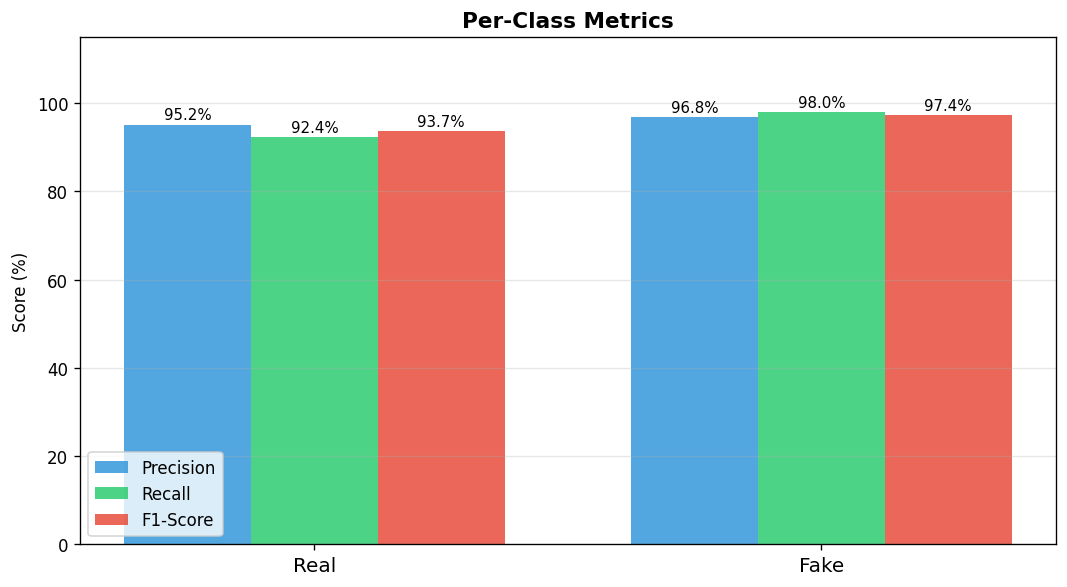

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = {
    'Precision': [precision_score(all_labels, all_preds, pos_label=0),
                  precision_score(all_labels, all_preds, pos_label=1)],
    'Recall':    [recall_score(all_labels, all_preds, pos_label=0),
                  recall_score(all_labels, all_preds, pos_label=1)],
    'F1-Score':  [f1_score(all_labels, all_preds, pos_label=0),
                  f1_score(all_labels, all_preds, pos_label=1)],
}

x = np.arange(2)
width = 0.25
colors = ['#3498db','#2ecc71','#e74c3c']
fig, ax = plt.subplots(figsize=(9, 5))
for i, (metric, vals) in enumerate(metrics.items()):
    bars = ax.bar(x + i*width, [v*100 for v in vals], width,
                  label=metric, color=colors[i], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_title("Per-Class Metrics", fontsize=13, fontweight='bold')
ax.set_xticks(x + width); ax.set_xticklabels(['Real','Fake'], fontsize=12)
ax.set_ylabel("Score (%)"); ax.set_ylim(0, 115)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Sample Test Predictions — Correct vs Incorrect

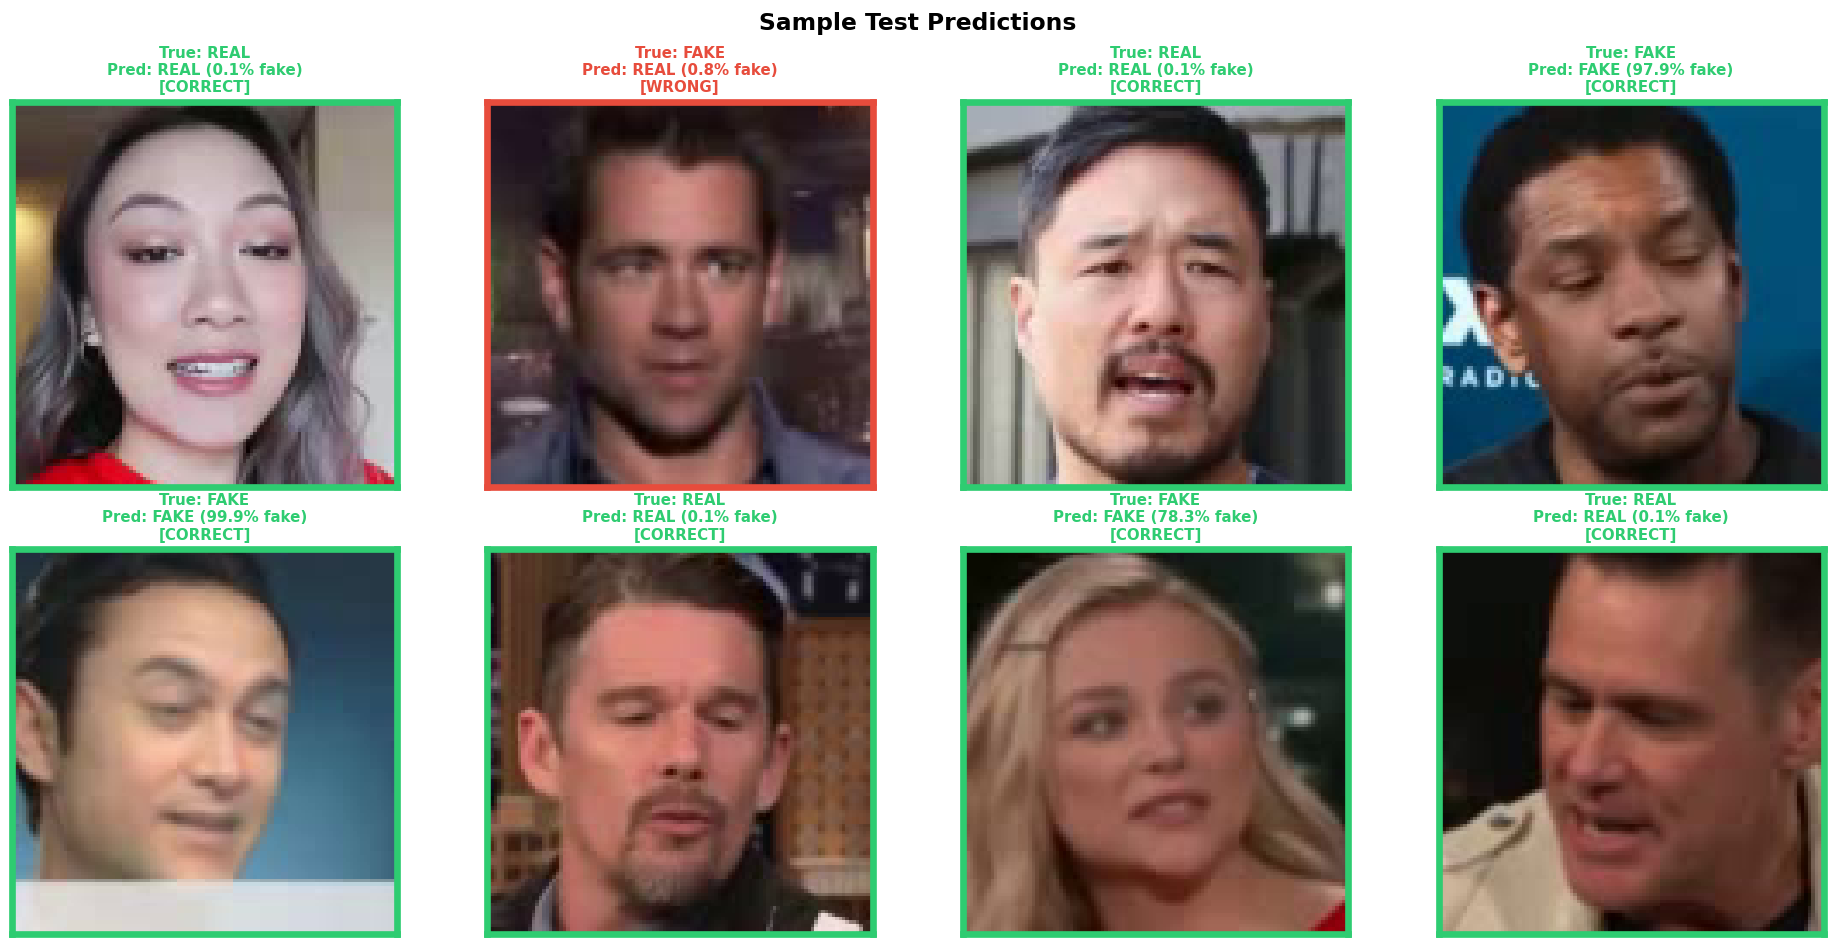

In [20]:
def get_video_prediction(video_path, label):
    cap = cv2.VideoCapture(video_path)
    frames, thumb = [], None
    while len(frames) < FRAMES_PER_VIDEO and cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        if thumb is None:
            thumb = cv2.resize(rgb, (112,112))
        frames.append(val_transform(cv2.resize(rgb,(224,224))))
    cap.release()
    while len(frames) < FRAMES_PER_VIDEO:
        frames.append(torch.zeros(3,224,224))
    tensor = torch.stack(frames).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0]
    pred = torch.argmax(probs).item()
    return pred, probs[1].item(), thumb

# Collect sample predictions from test set
real_test = [os.path.join(SPLIT_DIR,"real","test",f)
             for f in os.listdir(os.path.join(SPLIT_DIR,"real","test")) if f.endswith(".mp4")]
fake_test = [os.path.join(SPLIT_DIR,"fake","test",f)
             for f in os.listdir(os.path.join(SPLIT_DIR,"fake","test")) if f.endswith(".mp4")]

samples = [(v,0) for v in random.sample(real_test, min(4,len(real_test)))] +           [(v,1) for v in random.sample(fake_test, min(4,len(fake_test)))]
random.shuffle(samples)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Sample Test Predictions", fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, (vpath, true_label) in enumerate(samples[:8]):
    pred, fake_prob, thumb = get_video_prediction(vpath, true_label)
    correct = pred == true_label
    true_str = "REAL" if true_label == 0 else "FAKE"
    pred_str = "REAL" if pred == 0 else "FAKE"
    border_color = "#2ecc71" if correct else "#e74c3c"
    status = "CORRECT" if correct else "WRONG"

    if thumb is not None:
        axes[i].imshow(thumb)
    for spine in axes[i].spines.values():
        spine.set_edgecolor(border_color); spine.set_linewidth(4)
    axes[i].set_title(
        f"True: {true_str}\nPred: {pred_str} ({fake_prob*100:.1f}% fake)\n[{status}]",
        color=border_color, fontsize=9, fontweight='bold')
    axes[i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.tight_layout()
plt.show()

## Step 11 — Predict on a New Video
Upload any `.mp4` video to get a **Real / Fake** verdict with confidence score and per-frame breakdown.

In [33]:
import os
fake_dir = "/kaggle/input/datasets/arcticfoz/celeb-df-processed/processed/fake"
files = os.listdir(fake_dir)[:5]
for f in files:
    print(f)


id33_id20_0005.mp4
id51_id50_0008.mp4
id22_id19_0006.mp4
id52_id49_0008.mp4
id35_id4_0006.mp4


Running inference on: /kaggle/input/datasets/arcticfoz/celeb-df-processed/processed/fake/id33_id20_0005.mp4

  VERDICT     : FAKE
  Confidence  : 80.46%
  Real prob   : 19.54%
  Fake prob   : 80.46%


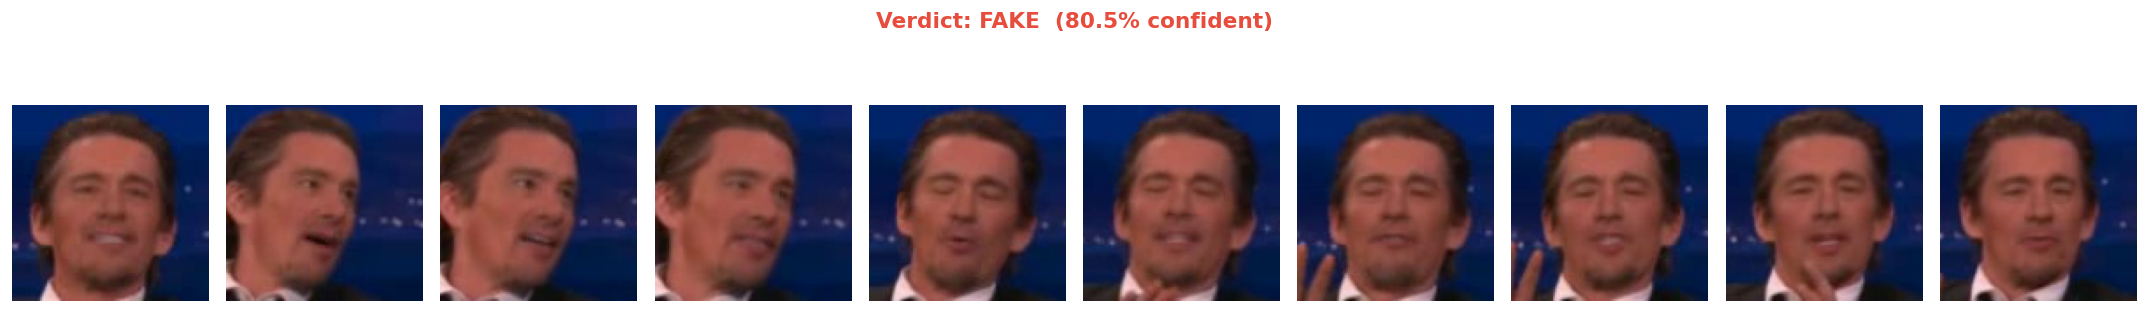

In [34]:
from torchvision import transforms as T

infer_tf = T.Compose([
    T.ToPILImage(),
    T.ToTensor(),
    T.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

def predict_new_video(path):
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total-1, FRAMES_PER_VIDEO, dtype=int)
    frames, thumbnails = [], []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret: continue
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        thumbnails.append(cv2.resize(rgb, (112, 112)))
        frames.append(infer_tf(cv2.resize(rgb, (224, 224))))
    cap.release()
    while len(frames) < FRAMES_PER_VIDEO:
        frames.append(torch.zeros(3, 224, 224))

    tensor = torch.stack(frames).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0]

    pred  = torch.argmax(probs).item()
    label = "FAKE" if pred == 1 else "REAL"
    return label, probs[0].item(), probs[1].item(), thumbnails

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

# On Kaggle: point this to your video file
# - Add a dataset containing your video via "Add Data" on the right panel
# - Or use the Files panel to upload directly
video_path = "/kaggle/input/datasets/arcticfoz/celeb-df-processed/processed/fake/id33_id20_0005.mp4"
  # <-- CHANGE THIS

assert os.path.exists(video_path), f"Video not found: {video_path}"
print(f"Running inference on: {video_path}")

label, real_p, fake_p, thumbs = predict_new_video(video_path)
conf = fake_p*100 if label == "FAKE" else real_p*100
color = "#e74c3c" if label == "FAKE" else "#2ecc71"

print()
print("=" * 44)
print(f"  VERDICT     : {label}")
print(f"  Confidence  : {conf:.2f}%")
print(f"  Real prob   : {real_p*100:.2f}%")
print(f"  Fake prob   : {fake_p*100:.2f}%")
print("=" * 44)

n_show = min(10, len(thumbs))
fig, axes = plt.subplots(1, n_show, figsize=(18, 3))
fig.suptitle(f"Verdict: {label}  ({conf:.1f}% confident)",
             fontsize=13, fontweight="bold", color=color)
for i, ax in enumerate(axes):
    ax.imshow(thumbs[i * (len(thumbs)//n_show)])
    ax.axis("off")
plt.tight_layout()
plt.show()
